<!-- project-notebook-context -->
# Image Restoration Benchmark - PSNR Quality Metrics Legacy Notebook

**Current project:** `image-restoration-benchmark`

**Notebook role:** Legacy notebook that explored PSNR calculation after noise and filtering. The current project evaluates MAE, MSE, PSNR, and global SSIM through the benchmark pipeline.

## Current project entry points

- `image_restoration_benchmark/metrics.py`
- `scripts/run_benchmark.py`

## Maintenance notes

- This notebook is retained for continuity with the original experiment.
- Current metrics are exported to CSV and JSON by the benchmark command.

---



In [1]:
import numpy as np
import cv2 as cv
import glob
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [2]:
# --- Reproducible-run setup (uses an open-source natural sample image) ---
import os, warnings
from pathlib import Path
import numpy as np
import cv2 as cv

warnings.filterwarnings('ignore')
_NB_DIR = Path.cwd()
_RUN_DIR = (_NB_DIR / '..' / 'outputs').resolve()
_RUN_DIR.mkdir(parents=True, exist_ok=True)
_SRC = (_NB_DIR / '../sample/cameraman.png').resolve()


def _prepare_input(name, max_side=160):
    img = cv.imread(str(_SRC))
    if img is None:
        raise FileNotFoundError(f'Natural sample image not found: {_SRC}')
    h, w = img.shape[:2]
    s = max_side / max(h, w)
    if s < 1.0:
        img = cv.resize(img, (int(w * s), int(h * s)), interpolation=cv.INTER_AREA)
    dst = _RUN_DIR / name
    cv.imwrite(str(dst), img)
    print('Using natural sample:', _SRC.name, '->', img.shape)
    return dst


_prepare_input('1.jpg')
os.chdir(_RUN_DIR)
print('Run dir:', _RUN_DIR)


Using natural sample: cameraman.png -> (160, 160, 3)
Run dir: C:\work\p\github-repos\private\image-restoration-benchmark\legacy\psnr-quality-metrics\outputs


In [3]:
image = cv.imread('1.jpg',cv.IMREAD_GRAYSCALE)

In [4]:
cv.imwrite("gray.jpg", image)

True

In [5]:
def gaussian_noise(img, mean=0, sigma=0.5):
    img = img / 255.0
    noise = np.random.normal(mean, sigma, img.shape)
    img = img + noise
    img = np.clip(img, 0, 1)
    img = np.uint8(img*255)
 
    return img

In [6]:
def median_filter(image,size):
    H,W = image.shape    
    
    pad = size // 2
    
    out = np.zeros((H + pad*2, W + pad*2), dtype=np.float64)
    
    out[pad:pad+H, pad:pad+W] = image.copy().astype(np.float64)
    
    tmp = out.copy()

    for y in range(H):
        for x in range(W):
            out[pad+y, pad+x] = np.median(tmp[y:y+size, x:x+size])
    
    out = out[pad:pad+H, pad:pad+W].astype(np.uint8)
    
    return out

In [7]:
def psnr(img1, img2):
    mse = np.mean( (img1/255. - img2/255.) ** 2 )
    if mse < 1.0e-10:
        return 100
    PIXEL_MAX = 1
    
    return 20 * math.log10(PIXEL_MAX / math.sqrt(mse))

In [8]:
image1 = gaussian_noise(image)

image2 = gaussian_noise(image)

In [9]:
cv.imwrite("noise_2.jpg", image1)

True

In [10]:
p3_1 = median_filter(image1,3)

p3_2 = median_filter(p3_1,3)

cv.imwrite("p3_2.jpg", p3_2)

True

In [11]:
p5 = median_filter(image2,5)

cv.imwrite("p5_2.jpg", p5)

True

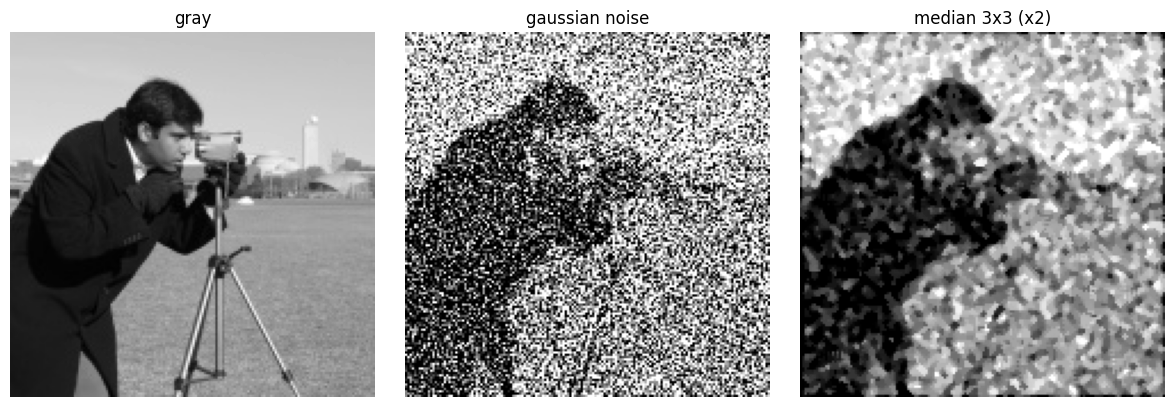

PSNR(p3_2 vs p5) = 14.582294834569737


In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, im, t in zip(ax, [image, image1, p3_2], ['gray', 'gaussian noise', 'median 3x3 (x2)']):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()
print('PSNR(p3_2 vs p5) =', psnr(p3_2, p5))